<a href="https://colab.research.google.com/github/jangrakrish-arch/-cyber-assignment-1/blob/main/assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Load the CSV file
df = pd.read_csv('/content/simple_cyber_messages.csv')

# Display first 5 rows
display(df.head())

# Display dataset shape
print("Dataset shape:", df.shape)

,message_id,message,correct_category
0,1,The department meeting is scheduled for 2 PM i...,Safe
1,2,Your account will be suspended. Click here and...,Phishing
2,3,The attached executable file contains a trojan...,Malware
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware
4,5,Library books must be returned before Friday.,Safe


Dataset shape: (28, 3)


In [ ]:
manual_table = df.head(10)[
    ['message_id', 'message', 'correct_category']
].copy()

manual_table['important_words'] = [
    'meeting, scheduled',
    'suspended, click here, verify, password',
    'urgently',
    'executable, trojan, infect',
    'encrypted, bitcoin, restore files',
    'library, returned',
    'prize, login, claim',
    'spyware, attachment',
    'locked files, ransom, payment',
    'official portal'
]

display(manual_table)

,message_id,message,correct_category,important_words
0,1,The department meeting is scheduled for 2 PM i...,Safe,"meeting, scheduled"
1,2,Your account will be suspended. Click here and...,Phishing,"suspended, click here, verify, password"
2,3,The attached executable file contains a trojan...,Malware,urgently
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware,"executable, trojan, infect"
4,5,Library books must be returned before Friday.,Safe,"encrypted, bitcoin, restore files"
5,6,Congratulations! You won a prize. Login now to...,Phishing,"library, returned"
6,7,Antivirus detected spyware in the downloaded a...,Malware,"prize, login, claim"
7,8,Locked files will be released only after ranso...,Ransomware,"spyware, attachment"
8,9,Your monthly attendance report is available on...,Safe,"locked files, ransom, payment"
9,10,Urgent bank alert: verify account and share OT...,Phishing,official portal


In [ ]:
RULE_KEYWORDS = {
    'Phishing': [
        'click here',
        'verify',
        'password',
        'urgent',
        'otp',
        'prize',
        'bank',
        'login',
        'blocked'
    ],

    'Malware': [
        'malware',
        'virus',
        'infected',
        'attachment',
        'trojan',
        'spyware',
        'executable'
    ],

    'Ransomware': [
        'encrypted',
        'ransom',
        'bitcoin',
        'restore files',
        'locked files',
        'unlock',
        'payment demand'
    ]
}

print("Keyword lists created successfully.")

Keyword lists created successfully.


In [ ]:
def classify_message(text):
    text = str(text).lower()

    scores = {
        category: sum(word in text for word in words)
        for category, words in RULE_KEYWORDS.items()
    }

    predicted = max(scores, key=scores.get)

    # No suspicious keyword found
    if scores[predicted] == 0:
        return 'Safe', '', 0

    # Find matched keywords
    matched = [
        word for word in RULE_KEYWORDS[predicted]
        if word in text
    ]

    return predicted, ', '.join(matched), scores[predicted]

In [ ]:
test_messages = [
    "Urgent: click here to verify your password",
    "The college library book has been returned",
    "Your computer contains a trojan executable attachment",
    "Your files are encrypted. Pay bitcoin to restore files"
]

for message in test_messages:
    result = classify_message(message)
    print("Message:", message)
    print("Result:", result)
    print("-" * 70)

Message: Urgent: click here to verify your password
Result: ('Phishing', 'click here, verify, password, urgent', 4)
----------------------------------------------------------------------
Message: The college library book has been returned
Result: ('Safe', '', 0)
----------------------------------------------------------------------
Message: Your computer contains a trojan executable attachment
Result: ('Malware', 'attachment, trojan, executable', 3)
----------------------------------------------------------------------
Message: Your files are encrypted. Pay bitcoin to restore files
Result: ('Ransomware', 'encrypted, bitcoin, restore files', 3)
----------------------------------------------------------------------


In [ ]:
results = df['message'].apply(classify_message)

df[
    ['predicted_category', 'matched_keywords', 'keyword_score']
] = pd.DataFrame(
    results.tolist(),
    index=df.index
)

# Check whether prediction is correct
df['correct'] = (
    df['correct_category'] ==
    df['predicted_category']
)

# Calculate accuracy
accuracy = accuracy_score(
    df['correct_category'],
    df['predicted_category']
)

# Display result
display(df[
    [
        'message_id',
        'correct_category',
        'predicted_category',
        'matched_keywords',
        'keyword_score',
        'correct'
    ]
])

,message_id,correct_category,predicted_category,matched_keywords,keyword_score,correct
0,1,Safe,Safe,,0,True
1,2,Phishing,Phishing,"click here, verify, password, urgent",4,True
2,3,Malware,Malware,"trojan, executable",2,True
3,4,Ransomware,Ransomware,"encrypted, bitcoin, restore files",3,True
4,5,Safe,Safe,,0,True
5,6,Phishing,Phishing,"prize, login",2,True
6,7,Malware,Malware,"virus, attachment, spyware",3,True
7,8,Ransomware,Ransomware,"ransom, locked files",2,True
8,9,Safe,Safe,,0,True
9,10,Phishing,Phishing,"verify, urgent, otp, bank",4,True


In [ ]:
correct_predictions = df['correct'].sum()
incorrect_predictions = len(df) - correct_predictions

print("Total messages:", len(df))
print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

Total messages: 28
Correct predictions: 27
Incorrect predictions: 1
Accuracy: 96.43%


In [ ]:
def add_risk_and_action(row):

    if row['predicted_category'] == 'Safe':
        return (
            'Low',
            'Continue normal caution.'
        )

    elif (
        row['predicted_category'] == 'Ransomware'
        or row['keyword_score'] >= 2
    ):
        return (
            'High',
            'Do not click/open; isolate if required and report.'
        )

    else:
        return (
            'Medium',
            'Do not interact; verify the sender and report.'
        )

In [ ]:
risk_output = df.apply(
    add_risk_and_action,
    axis=1
)

df[
    ['risk_level', 'recommended_action']
] = pd.DataFrame(
    risk_output.tolist(),
    index=df.index
)

display(df[
    [
        'message_id',
        'predicted_category',
        'keyword_score',
        'risk_level',
        'recommended_action'
    ]
])

,message_id,predicted_category,keyword_score,risk_level,recommended_action
0,1,Safe,0,Low,Continue normal caution.
1,2,Phishing,4,High,Do not click/open; isolate if required and rep...
2,3,Malware,2,High,Do not click/open; isolate if required and rep...
3,4,Ransomware,3,High,Do not click/open; isolate if required and rep...
4,5,Safe,0,Low,Continue normal caution.
5,6,Phishing,2,High,Do not click/open; isolate if required and rep...
6,7,Malware,3,High,Do not click/open; isolate if required and rep...
7,8,Ransomware,2,High,Do not click/open; isolate if required and rep...
8,9,Safe,0,Low,Continue normal caution.
9,10,Phishing,4,High,Do not click/open; isolate if required and rep...


In [ ]:
category_order = [
    'Safe',
    'Phishing',
    'Malware',
    'Ransomware'
]

category_counts = (
    df['predicted_category']
    .value_counts()
    .reindex(
        category_order,
        fill_value=0
    )
)

print(category_counts)

predicted_category
Safe          8
Phishing      7
Malware       7
Ransomware    6
Name: count, dtype: int64


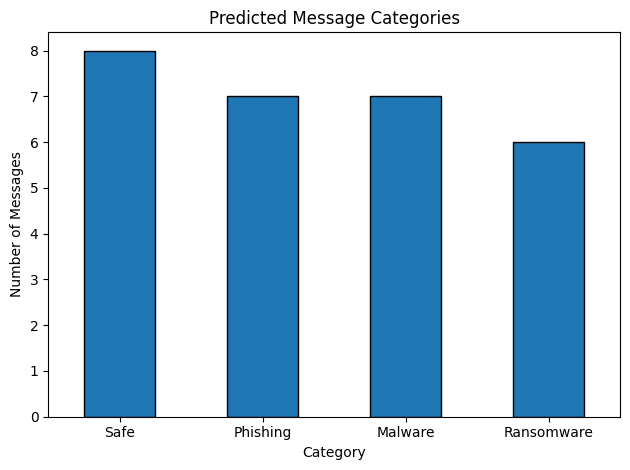

In [ ]:
category_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Predicted Message Categories')
plt.xlabel('Category')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
responsible_use = [
    'Privacy: Remove personal identifiers before analysis.',
    'Bias: Keyword lists may not cover every writing style or language.',
    'False alarms: Safe messages may contain warning words.',
    'Accountability: Humans remain responsible for final decisions.',
    'Human review: High-risk or unclear cases must be checked by a human.'
]

for point in responsible_use:
    print('-', point)

- Privacy: Remove personal identifiers before analysis.
- Bias: Keyword lists may not cover every writing style or language.
- False alarms: Safe messages may contain warning words.
- Accountability: Humans remain responsible for final decisions.
- Human review: High-risk or unclear cases must be checked by a human.
